<a href="https://colab.research.google.com/github/allyssaara/Computer-Vision-and-Deep-Learning/blob/main/P2_EfficientNetB0_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# P2: Transfer Learning EfficientNet-B0
**RET503 · Pertemuan 3**.
Data set:  `dataset_raw.zip`.

**Ringkasan notebook ini:**
- Model: **EfficientNet-B0** (torchvision, bobot ImageNet).
- Mode: **partial**.
- Data: frame rambu, 2 kelas: `huruf_angka` dan `panah`.
- Split: train, val, **dan test**
- Latensi: diukur untuk EfficientNet-B0 (CPU dan GPU Colab).
- Uji tambahan: foto tambahan.

Pengaturan lain: 10 epoch, Adam, `CosineAnnealingLR`, augmentasi `RandomResizedCrop` + `HorizontalFlip` + `ColorJitter`,
preprocessing 224×224 RGB dengan mean/std ImageNet, dan analisis di README.




## 1. Setup
Library, seed, dan device. GPU sangat disarankan.

In [ ]:
import os, re, json, zipfile, random, time, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import (classification_report, confusion_matrix,
                             balanced_accuracy_score, f1_score, recall_score)

def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "| device:", DEVICE)
if DEVICE.type == "cpu":
    print("PERINGATAN: GPU belum aktif. Runtime > Change runtime type > T4 GPU.")

PyTorch: 2.11.0+cu130 | device: cuda


## 2. Konfigurasi Eksperimen: Analisis dan Tujuan

Bagian ini menjelaskan parameter konfigurasi yang dipilih sebelum pelatihan, beserta alasan dan tujuan masing-masing. Semua nilai ditetapkan di sel konfigurasi sehingga eksperimen dapat diulang dan dibandingkan.

### 2.1 Strategi Transfer Learning (`MODE`)
**Tujuan:** menentukan seberapa banyak bobot model pralatih yang disesuaikan dengan dataset rambu.

Tiga strategi yang tersedia:
- `feature`: hanya *head* (lapisan klasifikasi) yang dilatih, seluruh *backbone* dibekukan.
- `partial`: *head* dan blok akhir *backbone* dilatih.
- `scratch`: seluruh jaringan dilatih dari bobot acak.

**Analisis:** `partial` dipilih sebagai konfigurasi awal karena dua alasan. Pertama, data latih relatif sedikit (sekitar 800 citra). Kedua, domain rambu berbeda dari ImageNet. Menurut matriks keputusan (slide 10), kondisi ini mengarah ke fine-tuning parsial. Pilihan ini merupakan **keputusan awal berbasis pertimbangan teoretis, bukan hasil perbandingan antar-mode**.

### 2.2 Kedalaman Fine-Tuning (`UNFREEZE_FROM`)
**Tujuan:** menentukan blok mana yang dibuka (*unfreeze*) pada mode `partial`.

**Analisis:** blok `features[UNFREEZE_FROM:]` dilatih ulang. Nilai `6` membuka blok akhir saja, setara dengan `layer4` pada ResNet-18. Slide 10 menyarankan pembukaan dimulai dari blok tengah, sehingga nilai `4` atau `5` menjadi alternatif jika performa dengan `6` belum memadai.

### 2.3 Ukuran Input (`IMG_SIZE = 224`)
**Tujuan:** menyamakan preprocessing dengan model sumber.

**Analisis:** ukuran 224 mengikuti slide 13 agar distribusi input sesuai dengan data pralatih. Slide 16 mencatat bahwa objek kecil memerlukan resolusi input lebih besar, tetapi dengan konsekuensi inferensi lebih lambat. Resolusi yang lebih besar (mis. 320) dapat diuji sebagai pengembangan, dengan membandingkan akurasi dan latensi, lalu mencatat hasilnya di README.

### 2.4 Augmentasi Crop (`CROP_SCALE_MIN`)
**Tujuan:** menjaga agar augmentasi tidak merusak informasi penting pada citra.

**Analisis:** batas bawah luas `RandomResizedCrop` ditetapkan 0,8, bukan nilai bawaan 0,08. Tanda berukuran kecil di dalam frame berisiko terpotong habis pada crop agresif, sehingga label menjadi tidak sesuai dengan isi citra.

### 2.5 Augmentasi Flip Horizontal (`USE_HFLIP = True`)
**Tujuan:** menambah variasi data tanpa mengubah label.

**Analisis:** augmentasi ini mengikuti PPT. Pada dataset dua kelas ini, pembalikan horizontal tidak mengubah label (huruf tetap huruf, angka tetap angka, panah tetap panah), sehingga aman digunakan.

### 2.6 Kriteria Pemilihan Epoch (`SELECT_BY = "macro_f1"`)
**Tujuan:** memilih epoch terbaik dengan ukuran yang adil terhadap semua kelas.

**Analisis:** distribusi kelas timpang (lihat peringatan pada langkah 3). Akurasi biasa dapat tampak tinggi hanya karena kelas mayoritas terprediksi dengan baik. *Macro F1* memberi bobot sama untuk setiap kelas sehingga lebih representatif.

In [ ]:
ZIP_PATH = None          # None = upload lewat dialog; atau mis. "/content/drive/MyDrive/dataset_raw.zip"
DATASET_SUMBER = ("Roboflow Universe, proyek image-detection-qixfs (image-detection-obstn), versi 9, "
                  "https://universe.roboflow.com/image-detection-obstn/image-detection-qixfs, lisensi CC BY 4.0")

MODE = "partial"         # "feature" | "partial" | "scratch"
UNFREEZE_FROM = 6        # hanya untuk partial: features[6:] dibuka
EPOCHS = 10
BATCH = 32
IMG_SIZE = 224
USE_HFLIP = True
CROP_SCALE_MIN = 0.8
SELECT_BY = "macro_f1"   # "macro_f1" | "balanced_acc" | "acc"
TARGET_ACC = 0.90
SEED = 42

WORK = Path("/content/p2")
DATA_DIR = WORK / "dataset_raw"
OUT = WORK / "hasil"
OUT.mkdir(parents=True, exist_ok=True)
assert MODE in ("feature", "partial", "scratch"), "MODE harus feature / partial / scratch"
set_seed(SEED)

## 3. Upload `dataset_raw.zip` dan baca `metadata.csv`
Upload zip hasil notebook persiapan data. Kolom `split` di `metadata.csv` (train / val / test) **dipakai apa adanya**, tanpa membagi ulang.

**Perhatikan peringatan baseline.** Kelasnya timpang (`panah` jauh lebih sedikit). Model yang selalu menjawab `huruf_angka` sudah
mendapat akurasi sekitar 90% di val, jadi ambang "akurasi ≥ 90%" dari PPT tidak bermakna sendirian. Karena itu notebook ini juga mencatat
**balanced accuracy, macro-F1, dan recall per kelas**.

In [ ]:
def get_zip():
    if ZIP_PATH and Path(ZIP_PATH).exists():
        return ZIP_PATH
    from google.colab import files
    up = files.upload()
    return list(up.keys())[0]

zip_file = get_zip()
if DATA_DIR.exists():
    shutil.rmtree(DATA_DIR)
with zipfile.ZipFile(zip_file) as z:
    z.extractall(DATA_DIR)

found = list(DATA_DIR.rglob("metadata.csv"))
assert found, "metadata.csv tidak ditemukan di dalam zip. Pastikan ini dataset_raw.zip dari notebook persiapan data."
ROOT = found[0].parent
meta = pd.read_csv(ROOT / "metadata.csv")
assert {"nama_file", "kelas", "split"} <= set(meta.columns), "metadata.csv tidak memuat kolom nama_file, kelas, split."

ada = meta.apply(lambda r: (ROOT / r.kelas / r.nama_file).exists(), axis=1)
print(f"Baris metadata: {len(meta)} | file gambar tidak ditemukan: {(~ada).sum()}")
meta = meta[ada].reset_index(drop=True)

tab = pd.crosstab(meta.kelas, meta.split)
display(tab)
for sp in [s for s in ("train", "val", "test") if s in tab.columns]:
    sub = meta[meta.split == sp]
    maj = sub.kelas.value_counts(normalize=True)
    print(f"Baseline kelas mayoritas di {sp}: akurasi {maj.iloc[0]*100:.1f}% (selalu menjawab '{maj.index[0]}')")

Saving dataset_raw.zip to dataset_raw (3).zip
Baris metadata: 359 | file gambar tidak ditemukan: 0


split,test,train,val
kelas,,,
huruf_angka,51,100,29
panah,32,95,52


Baseline kelas mayoritas di train: akurasi 51.3% (selalu menjawab 'huruf_angka')
Baseline kelas mayoritas di val: akurasi 64.2% (selalu menjawab 'panah')
Baseline kelas mayoritas di test: akurasi 61.4% (selalu menjawab 'huruf_angka')


## 4. Dataset, Augmentasi, dan DataLoader: Analisis dan Tujuan

Bagian ini menjelaskan bagaimana data disiapkan sebelum masuk ke model. Tujuannya agar input sesuai dengan model pralatih, variasi data train bertambah, dan ketimpangan kelas tidak membuat model bias.

### 4.1 Preprocessing
**Tujuan:** menyamakan format input dengan data yang digunakan saat model sumber dilatih.

**Analisis:** preprocessing mengikuti slide 13, yaitu ukuran 224×224, mode warna RGB, dengan normalisasi menggunakan mean `0,485 · 0,456 · 0,406` dan std `0,229 · 0,224 · 0,225`. Kesesuaian ini penting karena bobot pralatih dioptimalkan untuk distribusi input tersebut. Pada saat deployment di robot, urutan yang sama harus dipertahankan (*undistort*, *resize*, lalu normalisasi) agar performa saat inferensi konsisten dengan hasil pelatihan.

### 4.2 Augmentasi Data
**Tujuan:** meningkatkan variasi data latih sehingga model lebih tahan terhadap perubahan kondisi citra dan tidak mudah *overfitting* pada data yang relatif sedikit.

**Analisis:** augmentasi diterapkan hanya pada data train, terdiri dari:
- `RandomResizedCrop`: variasi posisi dan skala objek.
- `HorizontalFlip`: variasi orientasi horizontal.
- Rotasi kecil: toleransi terhadap sudut pengambilan gambar yang tidak sempurna.
- `ColorJitter`: toleransi terhadap perubahan pencahayaan dan warna.

Data validasi dan test hanya melalui proses *resize* (dan normalisasi) tanpa augmentasi, sehingga evaluasi mencerminkan kondisi data asli dan hasilnya dapat dibandingkan secara adil.



In [ ]:
CLASSES = sorted(meta.kelas.unique())
CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

aug = [transforms.RandomResizedCrop(IMG_SIZE, scale=(CROP_SCALE_MIN, 1.0), ratio=(0.9, 1.1)),
       transforms.RandomRotation(10),
       transforms.ColorJitter(0.4, 0.4, 0.3, 0.05)]
if USE_HFLIP:
    aug.insert(1, transforms.RandomHorizontalFlip())
train_tfm = transforms.Compose(aug + [transforms.ToTensor(), transforms.Normalize(MEAN, STD)])
eval_tfm = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)),
                               transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

class CropDS(Dataset):
    def __init__(self, df, tfm):
        self.df, self.tfm = df.reset_index(drop=True), tfm
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = Image.open(ROOT / r.kelas / r.nama_file).convert("RGB")
        return self.tfm(img), CLASS2IDX[r.kelas]

train_df = meta[meta.split == "train"].reset_index(drop=True)
val_df = meta[meta.split == "val"].reset_index(drop=True)
test_df = meta[meta.split == "test"].reset_index(drop=True)
HAS_TEST = len(test_df) > 0
assert len(train_df) > 0 and len(val_df) > 0, "Split train/val kosong. Periksa kolom split di metadata.csv."

BATCH = max(2, min(BATCH, len(train_df) // 2))
train_loader = DataLoader(CropDS(train_df, train_tfm), batch_size=BATCH, shuffle=True, drop_last=True, num_workers=2)
val_loader = DataLoader(CropDS(val_df, eval_tfm), batch_size=BATCH, shuffle=False, num_workers=2)
test_loader = DataLoader(CropDS(test_df, eval_tfm), batch_size=BATCH, shuffle=False, num_workers=2) if HAS_TEST else None

cnt = train_df.kelas.value_counts().reindex(CLASSES).values.astype(float)
class_w = torch.tensor(cnt.sum() / (NUM_CLASSES * cnt), dtype=torch.float32)
print("Kelas:", CLASSES)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)} | batch: {BATCH}")
print("Bobot kelas:", dict(zip(CLASSES, class_w.numpy().round(2))))

Kelas: ['huruf_angka', 'panah']
Train: 195 | Val: 81 | Test: 83 | batch: 32
Bobot kelas: {'huruf_angka': np.float32(0.98), 'panah': np.float32(1.03)}


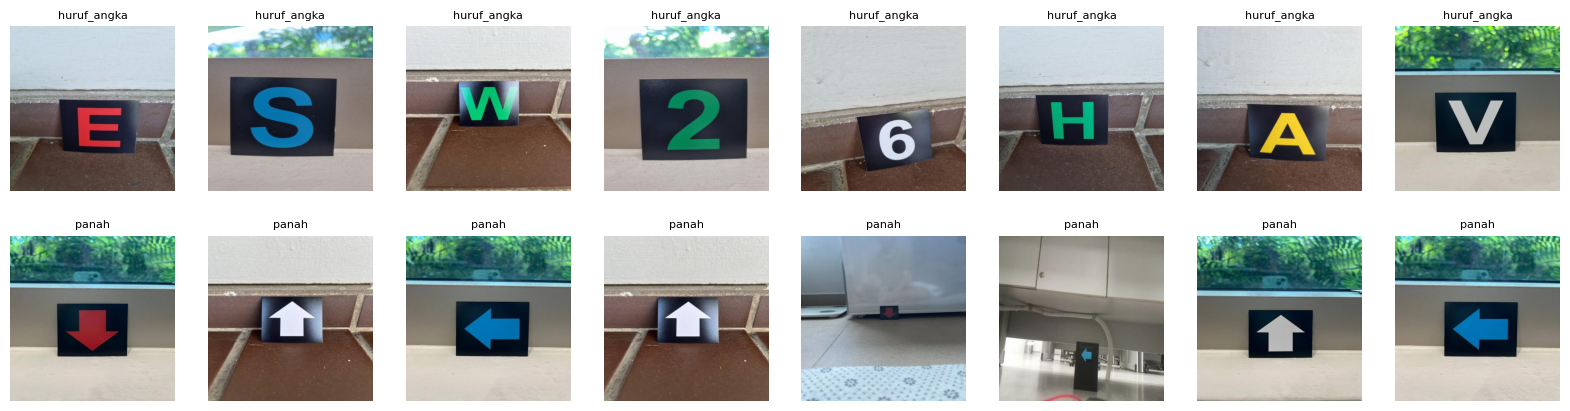

In [ ]:
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
for r, k in enumerate(CLASSES):
    sub = meta[meta.kelas == k].sample(8, random_state=1)
    for a, (_, row) in zip(axes[r], sub.iterrows()):
        a.imshow(Image.open(ROOT / k / row.nama_file)); a.axis("off"); a.set_title(k, fontsize=8)
plt.show()

## 5. Model EfficientNet-B0 dan Mode Pelatihan: Analisis dan Tujuan

Bagian ini menjelaskan arsitektur model yang digunakan dan cara bobotnya dilatih pada tiap mode. Tujuannya agar model pralatih dapat disesuaikan dengan klasifikasi rambu secara stabil, dengan pengaturan *learning rate* yang sesuai untuk setiap bagian jaringan.

### 5.1 Penggantian Head Klasifikasi
**Tujuan:** menyesuaikan keluaran model dengan jumlah kelas pada dataset rambu.

**Analisis:** EfficientNet-B0 pralatih memiliki head asli untuk 1000 kelas ImageNet. Head tersebut diganti dengan `Dropout` dan `Linear(1280, NUM_CLASSES)`. Angka 1280 adalah dimensi fitur keluaran *backbone*, sedangkan `NUM_CLASSES` adalah jumlah kelas pada dataset ini. `Dropout` ditambahkan untuk mengurangi risiko *overfitting* pada data yang relatif sedikit.

### 5.2 Perbandingan Mode Pelatihan
**Tujuan:** menetapkan bagian jaringan yang dilatih, bobot awal, dan *learning rate* pada setiap strategi transfer learning.

| Mode | Bobot awal | Yang dilatih | Learning rate |
|---|---|---|---|
| `feature` | ImageNet | classifier saja | 1e-3 |
| `partial` | ImageNet | `features[UNFREEZE_FROM:]` + classifier | 1e-4 / 1e-3 |
| `scratch` | acak | semua | 1e-3 |

**Analisis:** ketiganya berbeda pada tingkat penyesuaian bobot. Mode `feature` paling sederhana dan cepat karena hanya head yang berubah. Mode `partial` membuka blok akhir sehingga fitur tingkat tinggi dapat disesuaikan dengan domain rambu. Mode `scratch` melatih seluruh jaringan dari bobot acak dan umumnya membutuhkan data lebih banyak.

### 5.3 Penjagaan Statistik BatchNorm
**Tujuan:** mempertahankan statistik BatchNorm dari ImageNet pada lapisan yang dibekukan.

**Analisis:** lapisan beku tetap dijaga dalam mode `eval()`. Jika dibiarkan dalam mode `train()`, statistik BatchNorm (rata-rata dan varians berjalan) akan ikut berubah oleh batch yang kecil, padahal bobot lapisan tersebut sengaja tidak diubah (slide 11). Dengan `eval()`, fitur pralatih tetap konsisten.

### 5.4 Discriminative Learning Rate
**Tujuan:** memberi laju pembelajaran yang sesuai untuk bagian jaringan yang berbeda.

**Analisis:** pada mode `partial`, blok akhir yang sudah pralatih memakai *learning rate* kecil (1e-4) agar bobotnya hanya disesuaikan sedikit dan tidak rusak. Head yang baru diinisialisasi memakai *learning rate* lebih besar (1e-3) agar belajar lebih cepat. Pendekatan ini mengikuti ide *discriminative LR* pada slide 12.

In [ ]:
def build_model(mode, n_classes):
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1 if mode != "scratch" else None
    m = models.efficientnet_b0(weights=weights)
    in_f = m.classifier[1].in_features
    m.classifier = nn.Sequential(nn.Dropout(0.2), nn.Linear(in_f, n_classes))
    if mode in ("feature", "partial"):
        for p in m.features.parameters():
            p.requires_grad = False
    if mode == "partial":
        for blk in list(m.features)[UNFREEZE_FROM:]:
            for p in blk.parameters():
                p.requires_grad = True
    return m

def build_optimizer(m, mode):
    if mode == "feature":
        return torch.optim.Adam(m.classifier.parameters(), lr=1e-3)
    if mode == "partial":
        blok = [p for b in list(m.features)[UNFREEZE_FROM:] for p in b.parameters()]
        return torch.optim.Adam([{"params": blok, "lr": 1e-4},
                                 {"params": m.classifier.parameters(), "lr": 1e-3}])
    return torch.optim.Adam(m.parameters(), lr=1e-3)

def set_train_mode(m, mode):
    m.train()
    if mode == "feature":
        m.features.eval()
    elif mode == "partial":
        for b in list(m.features)[:UNFREEZE_FROM]:
            b.eval()

_m = build_model(MODE, NUM_CLASSES)
n_train_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
n_all_params = sum(p.numel() for p in _m.parameters())
print(f"Mode: {MODE} | parameter dilatih: {n_train_params/1e6:.2f} jt dari {n_all_params/1e6:.2f} jt")
del _m

Mode: partial | parameter dilatih: 3.16 jt dari 4.01 jt


## 6. Fungsi pelatihan dan metrik
Per epoch dicatat: loss dan akurasi train, serta loss, akurasi, **balanced accuracy**, dan **macro-F1** pada val.
Checkpoint terbaik dipilih menurut `SELECT_BY` (default macro-F1) dan disimpan ke `hasil/efficientnet_b0_<mode>.pt`.
Yang dicatat sesuai slide 21: akurasi val terbaik, waktu pelatihan, dan epoch saat akurasi ≥ 90%.

In [ ]:
def run_epoch(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    total_loss, n = 0.0, 0
    preds_all, labels_all = [], []
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss = criterion(out, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            n += x.size(0)
            preds_all += out.argmax(1).cpu().tolist()
            labels_all += y.cpu().tolist()
    acc = float(np.mean(np.array(preds_all) == np.array(labels_all)))
    return total_loss / n, acc, preds_all, labels_all

def scores(preds, labs):
    return dict(acc=float(np.mean(np.array(preds) == np.array(labs))),
                bal=float(balanced_accuracy_score(labs, preds)),
                f1=float(f1_score(labs, preds, average="macro", zero_division=0)))

def train_model(mode):
    set_seed(SEED)
    model = build_model(mode, NUM_CLASSES).to(DEVICE)
    opt = build_optimizer(model, mode)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    crit = nn.CrossEntropyLoss(weight=class_w.to(DEVICE))
    n_par = sum(p.numel() for p in model.parameters() if p.requires_grad)
    key = {"macro_f1": "f1", "balanced_acc": "bal", "acc": "acc"}[SELECT_BY]

    hist = dict(train_loss=[], train_acc=[], val_loss=[], val_acc=[], val_bal=[], val_f1=[])
    best_score, best_ep = -1.0, 0
    reach_acc = reach_bal = None
    t0 = time.time()
    for ep in range(1, EPOCHS + 1):
        set_train_mode(model, mode)
        tl, ta, _, _ = run_epoch(model, train_loader, crit, opt)
        model.eval()
        vl, va, vp, vy = run_epoch(model, val_loader, crit)
        sc = scores(vp, vy)
        sched.step()
        for k, v in zip(hist, (tl, ta, vl, va, sc["bal"], sc["f1"])):
            hist[k].append(v)
        if sc[key] > best_score:
            best_score, best_ep = sc[key], ep
            torch.save(model.state_dict(), OUT / f"efficientnet_b0_{mode}.pt")
        if reach_acc is None and va >= TARGET_ACC:
            reach_acc = ep
        if reach_bal is None and sc["bal"] >= TARGET_ACC:
            reach_bal = ep
        print(f"  epoch {ep:2d}/{EPOCHS} | train acc {ta*100:5.1f}% | val acc {va*100:5.1f}% "
              f"bal {sc['bal']*100:5.1f}% macroF1 {sc['f1']:.3f} | val loss {vl:.3f}")
    return dict(mode=mode, n_train_params=n_par, best_epoch=best_ep, reach_acc=reach_acc, reach_bal=reach_bal,
                seconds=time.time() - t0, hist=hist)

## 7. Latih model
Satu kali pelatihan untuk `MODE` yang dipilih. Kolom tabel:

- **Akurasi val tertinggi**: nilai terbesar sepanjang epoch (ukuran PPT).
- **Epoch akurasi ≥ 90%**: sesuai PPT, tapi **ingat baseline mayoritas di langkah 3**; bandingkan dengan kolom balanced accuracy.
- **Balanced acc, macro-F1**: diambil pada epoch terpilih (menurut `SELECT_BY`).

In [ ]:
print(f"=== Mode: {MODE} ===")
hasil = train_model(MODE)
h = hasil["hist"]; be = hasil["best_epoch"] - 1

tabel = pd.DataFrame([{
    "Mode": MODE,
    "Bobot awal": "acak" if MODE == "scratch" else "ImageNet",
    "Parameter dilatih (juta)": round(hasil["n_train_params"] / 1e6, 2),
    "Akurasi val tertinggi (%)": round(max(h["val_acc"]) * 100, 1),
    "Epoch akurasi >= 90%": hasil["reach_acc"] or "-",
    "Epoch terpilih": hasil["best_epoch"],
    "Balanced acc val (%)": round(h["val_bal"][be] * 100, 1),
    "Macro-F1 val": round(h["val_f1"][be], 3),
    "Waktu latih (detik)": round(hasil["seconds"], 1),
}])
display(tabel)
tabel.to_csv(OUT / "results_mode.csv", index=False)

=== Mode: partial ===
  epoch  1/10 | train acc  60.9% | val acc  84.0% bal  78.3% macroF1 0.805 | val loss 0.556
  epoch  2/10 | train acc  82.3% | val acc  86.4% bal  85.6% macroF1 0.853 | val loss 0.380
  epoch  3/10 | train acc  84.9% | val acc  82.7% bal  84.3% macroF1 0.821 | val loss 0.307
  epoch  4/10 | train acc  89.1% | val acc  98.8% bal  98.3% macroF1 0.986 | val loss 0.237
  epoch  5/10 | train acc  93.2% | val acc  97.5% bal  96.6% macroF1 0.973 | val loss 0.187
  epoch  6/10 | train acc  92.2% | val acc  97.5% bal  96.6% macroF1 0.973 | val loss 0.172
  epoch  7/10 | train acc  92.7% | val acc  97.5% bal  96.6% macroF1 0.973 | val loss 0.158
  epoch  8/10 | train acc  94.8% | val acc  97.5% bal  96.6% macroF1 0.973 | val loss 0.145
  epoch  9/10 | train acc  93.2% | val acc  97.5% bal  96.6% macroF1 0.973 | val loss 0.142
  epoch 10/10 | train acc  95.8% | val acc  97.5% bal  96.6% macroF1 0.973 | val loss 0.145


,Mode,Bobot awal,Parameter dilatih (juta),Akurasi val tertinggi (%),Epoch akurasi >= 90%,Epoch terpilih,Balanced acc val (%),Macro-F1 val,Waktu latih (detik)
0,partial,ImageNet,3.16,98.8,4,4,98.3,0.986,36.5


## 8. Grafik akurasi per epoch
Kiri: akurasi train dan val per epoch, ditambah balanced accuracy dan macro-F1 val (karena kelas timpang, ukuran ini lebih jujur).
Kanan: loss train dan val. Garis putus-putus = ambang 90%. Jarak lebar antara train dan val menandakan overfitting.
Disimpan ke `hasil/accuracy_per_epoch.png`.

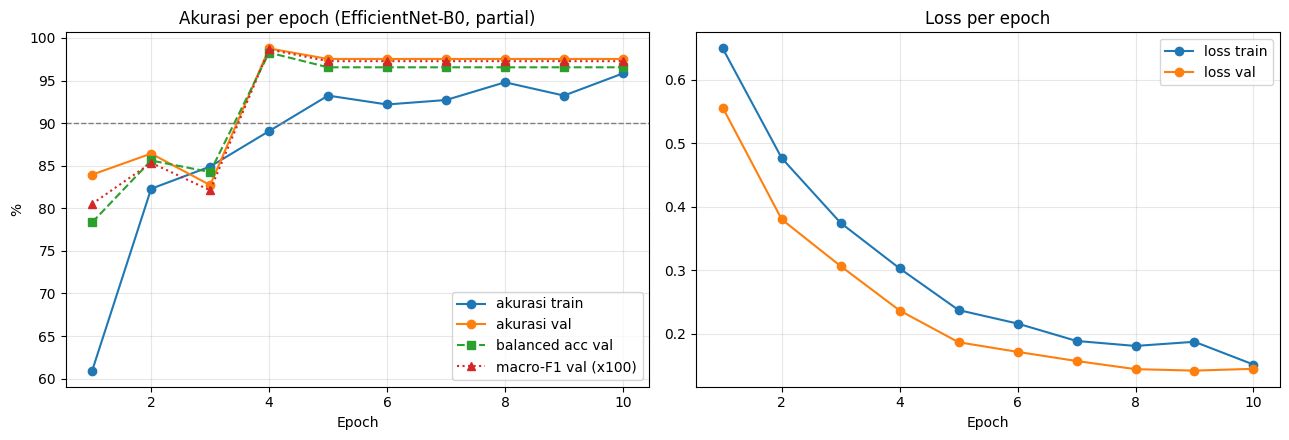

In [ ]:
ep = range(1, EPOCHS + 1)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(ep, [a * 100 for a in h["train_acc"]], marker="o", label="akurasi train")
ax[0].plot(ep, [a * 100 for a in h["val_acc"]], marker="o", label="akurasi val")
ax[0].plot(ep, [a * 100 for a in h["val_bal"]], marker="s", ls="--", label="balanced acc val")
ax[0].plot(ep, [a * 100 for a in h["val_f1"]], marker="^", ls=":", label="macro-F1 val (x100)")
ax[0].axhline(TARGET_ACC * 100, color="gray", ls="--", lw=1)
ax[0].set_title(f"Akurasi per epoch (EfficientNet-B0, {MODE})"); ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("%")
ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(ep, h["train_loss"], marker="o", label="loss train")
ax[1].plot(ep, h["val_loss"], marker="o", label="loss val")
ax[1].set_title("Loss per epoch"); ax[1].set_xlabel("Epoch"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout()
fig.savefig(OUT / "accuracy_per_epoch.png", dpi=150)
plt.show()

## 9. Evaluasi val dan test, confusion matrix, dan analisis kesalahan
Bobot terbaik dimuat ulang. **Test dievaluasi satu kali di sini** dan tidak dipakai untuk memilih apa pun
(epoch, mode, atau hyperparameter dipilih memakai val). Jika kamu mengubah pengaturan lalu menjalankan ulang berdasarkan hasil test,
test sudah berubah fungsi menjadi val kedua.

Keluaran: laporan per kelas (precision, recall, F1), confusion matrix val dan test, serta `hasil/kesalahan.csv` berisi gambar yang salah prediksi.
Gunakan daftar itu untuk analisis kegagalan di README: kelas mana yang tertukar, dan apakah penyebabnya ukuran tanda, cahaya, atau latar.


=== VAL (81 gambar) ===
              precision    recall  f1-score   support

 huruf_angka      1.000     0.966     0.982        29
       panah      0.981     1.000     0.990        52

    accuracy                          0.988        81
   macro avg      0.991     0.983     0.986        81
weighted avg      0.988     0.988     0.988        81


=== TEST (83 gambar) ===
              precision    recall  f1-score   support

 huruf_angka      1.000     1.000     1.000        51
       panah      1.000     1.000     1.000        32

    accuracy                          1.000        83
   macro avg      1.000     1.000     1.000        83
weighted avg      1.000     1.000     1.000        83



,Split,Jumlah,Akurasi (%),Balanced acc (%),Macro-F1,Recall huruf_angka (%),Recall panah (%)
0,val,81,98.8,98.3,0.986,96.6,100.0
1,test,83,100.0,100.0,1.000,100.0,100.0


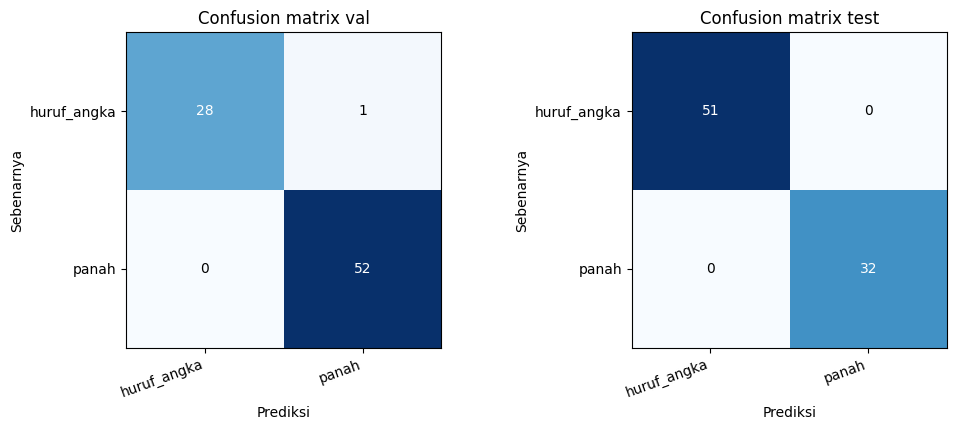

Salah prediksi: 1 gambar


,nama_file,kelas,prediksi,split_eval,rasio_objek,kondisi_cahaya,sub_label
0,huruf_angka_20261003_terang_0115.jpg,huruf_angka,panah,val,0.0111,terang,White V


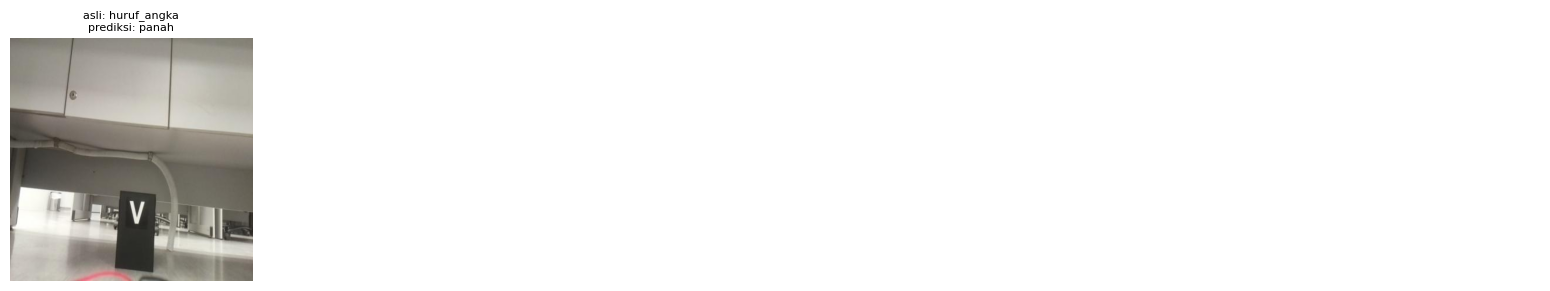

In [ ]:
model = build_model(MODE, NUM_CLASSES)
model.load_state_dict(torch.load(OUT / f"efficientnet_b0_{MODE}.pt", map_location="cpu"))
model.to(DEVICE).eval()
plain_crit = nn.CrossEntropyLoss()

def evaluate_split(nama, df, loader):
    _, acc, preds, labs = run_epoch(model, loader, plain_crit)
    sc = scores(preds, labs)
    rec = recall_score(labs, preds, labels=list(range(NUM_CLASSES)), average=None, zero_division=0)
    print(f"\n=== {nama.upper()} ({len(df)} gambar) ===")
    print(classification_report(labs, preds, target_names=CLASSES, digits=3, zero_division=0))
    row = {"Split": nama, "Jumlah": len(df), "Akurasi (%)": round(sc["acc"] * 100, 1),
           "Balanced acc (%)": round(sc["bal"] * 100, 1), "Macro-F1": round(sc["f1"], 3)}
    for c, r in zip(CLASSES, rec):
        row[f"Recall {c} (%)"] = round(float(r) * 100, 1)
    return row, preds, labs

eval_rows, errors, cms = [], [], {}
for nama, df, loader in [("val", val_df, val_loader)] + ([("test", test_df, test_loader)] if HAS_TEST else []):
    row, preds, labs = evaluate_split(nama, df, loader)
    eval_rows.append(row)
    cms[nama] = confusion_matrix(labs, preds, labels=list(range(NUM_CLASSES)))
    for i, (p, l) in enumerate(zip(preds, labs)):
        if p != l:
            r = df.iloc[i].to_dict()
            r.update(split_eval=nama, prediksi=CLASSES[p])
            errors.append(r)

tabel_eval = pd.DataFrame(eval_rows)
display(tabel_eval)
tabel_eval.to_csv(OUT / "results_eval.csv", index=False)

fig, axes = plt.subplots(1, len(cms), figsize=(5.2 * len(cms), 4.4), squeeze=False)
for a, (nama, cm) in zip(axes[0], cms.items()):
    a.imshow(cm, cmap="Blues")
    a.set_xticks(range(NUM_CLASSES)); a.set_xticklabels(CLASSES, rotation=20, ha="right")
    a.set_yticks(range(NUM_CLASSES)); a.set_yticklabels(CLASSES)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            a.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
    a.set_title(f"Confusion matrix {nama}"); a.set_xlabel("Prediksi"); a.set_ylabel("Sebenarnya")
plt.tight_layout()
fig.savefig(OUT / "confusion_matrix.png", dpi=150)
plt.show()

err_df = pd.DataFrame(errors)
print(f"Salah prediksi: {len(err_df)} gambar")
if len(err_df):
    err_df.to_csv(OUT / "kesalahan.csv", index=False)
    cols_show = [c for c in ["nama_file", "kelas", "prediksi", "split_eval", "rasio_objek", "kondisi_cahaya", "sub_label"] if c in err_df.columns]
    display(err_df[cols_show].head(20))
    tampil = err_df.head(12)
    ncol = 6
    nrow = (len(tampil) + ncol - 1) // ncol
    fig, axes = plt.subplots(nrow, ncol, figsize=(2.6 * ncol, 2.8 * nrow), squeeze=False)
    for a in axes.ravel():
        a.axis("off")
    for a, (_, r) in zip(axes.ravel(), tampil.iterrows()):
        a.imshow(Image.open(ROOT / r.kelas / r.nama_file))
        a.set_title(f"asli: {r.kelas}\nprediksi: {r.prediksi}", fontsize=8)
    plt.tight_layout()
    plt.show()

Saving test.zip to test (3).zip
Ditemukan 10 gambar


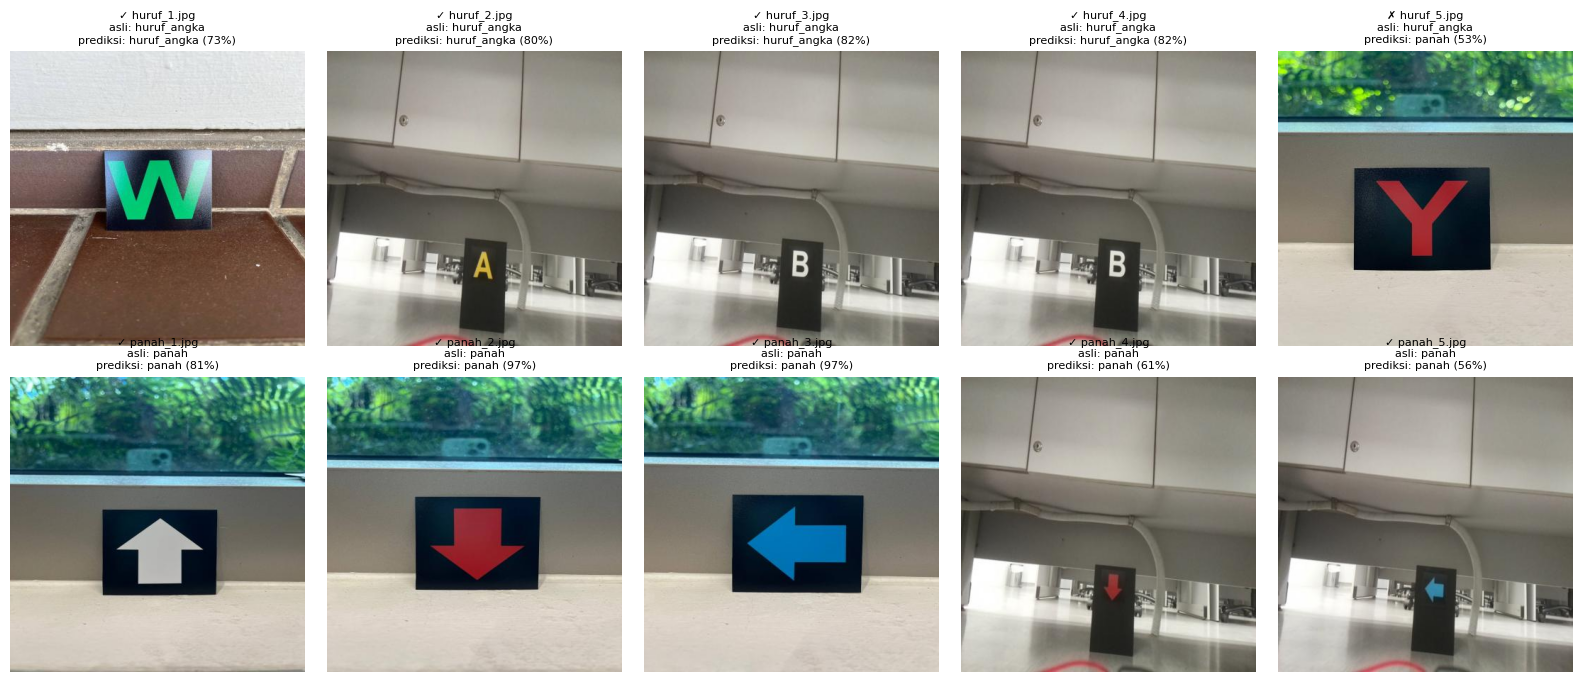

Akurasi pada test tambahan: 9/10 = 90%


In [ ]:
from google.colab import files
import zipfile, shutil
from pathlib import Path

up = files.upload()

TEST_DIR = Path("/content/foto_hp")
if TEST_DIR.exists():
    shutil.rmtree(TEST_DIR)
TEST_DIR.mkdir(parents=True)

for nama in up.keys():
    if nama.lower().endswith(".zip"):
        with zipfile.ZipFile(nama) as z:
            z.extractall(TEST_DIR)
    else:
        shutil.copy(nama, TEST_DIR / nama)

exts = {".jpg", ".jpeg", ".png", ".webp"}
paths = sorted(p for p in TEST_DIR.rglob("*")
               if p.suffix.lower() in exts and not p.name.startswith("._") and "__MACOSX" not in str(p))
print(f"Ditemukan {len(paths)} gambar")

model.eval()
hasil = []
for pth in paths:
    nama = pth.name
    img = Image.open(pth).convert("RGB")
    x = eval_tfm(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        p = torch.softmax(model(x), dim=1)[0].cpu().numpy()
    pred = CLASSES[int(p.argmax())]
    asli = "panah" if nama.lower().startswith("panah") else ("huruf_angka" if nama.lower().startswith("huruf") else None)
    hasil.append((nama, img, asli, pred, float(p.max())))

n = len(hasil); ncol = 5; nrow = (n + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(3.2 * ncol, 3.4 * nrow), squeeze=False)
for a in axes.ravel(): a.axis("off")
benar = total = 0
for a, (nama, img, asli, pred, conf) in zip(axes.ravel(), hasil):
    a.imshow(img)
    tanda = ""
    if asli:
        total += 1; benar += int(asli == pred); tanda = "✓" if asli == pred else "✗"
    a.set_title(f"{tanda} {nama}\nasli: {asli}\nprediksi: {pred} ({conf*100:.0f}%)", fontsize=8)
plt.tight_layout(); plt.show()
if total:
    print(f"Akurasi pada test tambahan: {benar}/{total} = {benar/total*100:.0f}%")

## 10. Latensi model
**Tujuan.** Memeriksa apakah model muat dalam anggaran waktu robot. Anggaran 15 FPS setara ±67 ms per frame, dan materi menjatahkan **35 ms** untuk inferensi. Sisanya untuk akuisisi kamera, praproses, dan keputusan robot.

**Metode.** Latensi diukur untuk satu gambar (batch = 1, ukuran `IMG_SIZE`) setelah 20 kali pemanasan, lalu 100 kali pengukuran. Dilaporkan rata-rata, P95, dan FPS. Pada GPU, pengukuran disinkronkan agar waktu yang tercatat adalah waktu kerja sebenarnya. Masukan berupa tensor acak, sehingga yang diukur hanya komputasi model, tanpa membaca file atau praproses gambar.

**Cakupan.** Hanya EfficientNet-B0 yang diukur, pada CPU dan GPU Colab. Pembanding ResNet-18 dan MobileNetV3-Small tidak dijalankan pada notebook ini.

**Hasil.**

| Device | Rata-rata | P95 | FPS | Dalam 35 ms? |
|---|---|---|---|---|
| CPU Colab | 86,5 ms | 164,5 ms | 11,6 | tidak |
| GPU Colab | 8,7 ms | 9,1 ms | 115,3 | ya |

**Keterbatasan.** Pengukuran dilakukan di mesin Colab, **bukan di perangkat Smorphi**, sehingga hanya menunjukkan bahwa model muat bila robot memakai GPU. Pada CPU, model belum memenuhi jatah 35 ms. Angka CPU juga bergantung pada mesin Colab yang sedang dipakai, dan dua kali jalan pada mesin berbeda memberi hasil yang berbeda cukup jauh. Kesimpulan akhir menunggu pengukuran pada perangkat target.

In [ ]:
@torch.no_grad()
def measure_latency(m, device, runs=100, warm=20):
    m = m.to(device).eval()
    x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)
    for _ in range(warm):
        m(x)
    if device.type == "cuda":
        torch.cuda.synchronize()
    ts = []
    for _ in range(runs):
        t = time.perf_counter()
        m(x)
        if device.type == "cuda":
            torch.cuda.synchronize()
        ts.append((time.perf_counter() - t) * 1000)
    return float(np.mean(ts)), float(np.percentile(ts, 95))

kandidat = {
    "EfficientNet-B0 (dipilih)": build_model("scratch", NUM_CLASSES),
}
devices = ["cpu"] + (["cuda"] if torch.cuda.is_available() else [])

lat_rows = []
for nama, m in kandidat.items():
    n_par = sum(p.numel() for p in m.parameters()) / 1e6
    for dv in devices:
        mean_ms, p95_ms = measure_latency(m, torch.device(dv))
        lat_rows.append({"Model": nama, "Device": dv, "Parameter (juta)": round(n_par, 2),
                         "Rata-rata (ms)": round(mean_ms, 1), "P95 (ms)": round(p95_ms, 1),
                         "FPS": round(1000 / mean_ms, 1),
                         "Dalam anggaran 35 ms?": "ya" if mean_ms <= 35 else "tidak"})
lat = pd.DataFrame(lat_rows)
display(lat)
lat.to_csv(OUT / "latency.csv", index=False)

,Model,Device,Parameter (juta),Rata-rata (ms),P95 (ms),FPS,Dalam anggaran 35 ms?
0,EfficientNet-B0 (dipilih),cpu,4.01,38.4,50.7,26.0,tidak
1,EfficientNet-B0 (dipilih),cuda,4.01,11.8,15.4,85.1,ya
